In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("telecom_churn.csv")
df

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0


In [3]:
df.shape

(3333, 11)

In [4]:
df['Churn'].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [5]:
df['Churn'].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [6]:
df.isnull().value_counts()

Churn  AccountWeeks  ContractRenewal  DataPlan  DataUsage  CustServCalls  DayMins  DayCalls  MonthlyCharge  OverageFee  RoamMins
False  False         False            False     False      False          False    False     False          False       False       3333
Name: count, dtype: int64

In [7]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [8]:
x=df.drop(columns=['Churn'])
y=df['Churn']

In [9]:
y

0       0
1       0
2       0
3       0
4       0
       ..
3328    0
3329    0
3330    0
3331    0
3332    0
Name: Churn, Length: 3333, dtype: int64

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [11]:
model=LogisticRegression()
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model.fit(x_train,y_train)


C:\Users\GARV\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
prediction=model.predict(x_test)
accuracy=accuracy_score(y_test,prediction)
print(f"accuracy is:{accuracy*100:.2f}")

accuracy is:84.90


In [14]:
new_x=df.drop(columns=['Churn'])
new_x.head()

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [15]:
x_new=(new_x-new_x.mean())/new_x.std()
x_new.head()

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0.676388,0.327531,1.616843,1.479982,-0.427868,1.566532,0.476572,1.990428,-0.071573,-0.084995
1,0.149043,0.327531,1.616843,2.265733,-0.427868,-0.333688,1.124334,1.564276,-0.107066,1.240296
2,0.902393,0.327531,-0.618303,-0.641546,-1.188040,1.168128,0.675883,-0.262094,-1.574109,0.703015
3,-0.428526,-3.052227,-0.618303,-0.641546,0.332305,2.196267,-1.466716,0.042301,-2.741435,-1.302831
4,-0.654531,-3.052227,-0.618303,-0.641546,1.092477,-0.240054,0.626055,-0.931763,-1.037771,-0.049177


In [16]:
x_new_train,x_new_test,y_train,y_test=train_test_split(x_new,y,test_size=0.3,random_state=42)
model.fit(x_new_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
new_pred=model.predict(x_new_test)
new_acc=accuracy_score(y_test,new_pred)
print(f"new accuracy is:{new_acc*100:.2f}")

new accuracy is:86.70


-----classification report-----
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       857
           1       0.60      0.20      0.30       143

    accuracy                           0.87      1000
   macro avg       0.74      0.59      0.62      1000
weighted avg       0.84      0.87      0.84      1000

-----confusion matrix-----


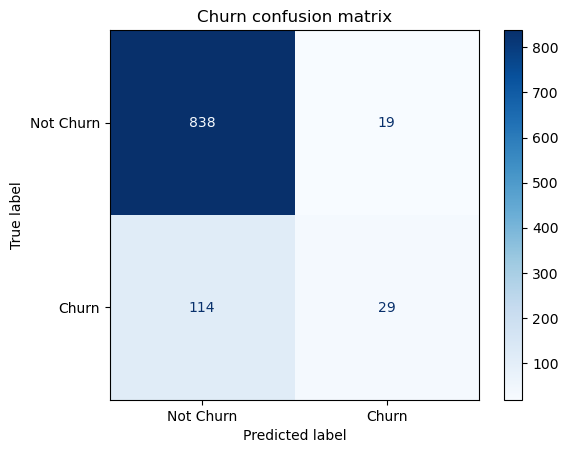

In [18]:
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
import matplotlib.pyplot as plt 

print("-----classification report-----")
print(classification_report(y_test,new_pred))

cm=confusion_matrix(y_test,new_pred)
print("-----confusion matrix-----")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Not Churn","Churn"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Churn confusion matrix")
plt.show()


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Initialize the model with the balanced weight!
# (Keep whatever max_iter or solver you used before, just add class_weight)
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)

# 2. Re-train the model on your standardized training data
model_balanced.fit(x_new_train, y_train) 

# 3. Make new predictions
y_pred_balanced = model_balanced.predict(x_new_test)

# 4. Print the new truth!
print("--- BALANCED Classification Report ---")
print(classification_report(y_test, y_pred_balanced))

--- BALANCED Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       857
           1       0.38      0.80      0.51       143

    accuracy                           0.78      1000
   macro avg       0.67      0.79      0.69      1000
weighted avg       0.88      0.78      0.81      1000



In [20]:
print(accuracy_score(y_test,y_pred_balanced))

0.782


--- RANDOM FOREST Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       857
           1       0.87      0.63      0.73       143

    accuracy                           0.93      1000
   macro avg       0.91      0.81      0.85      1000
weighted avg       0.93      0.93      0.93      1000



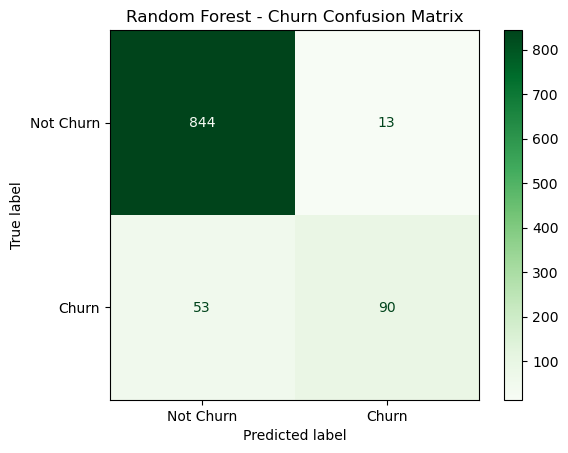

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize the Forest
# n_estimators=100 means we are planting exactly 100 trees
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Train all 100 trees simultaneously!
rf_model.fit(x_train, y_train)

# 3. Make the Predictions
y_pred_rf = rf_model.predict(x_test)

# 4. Print the Math Scores
print("--- RANDOM FOREST Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# 5. Draw the Visual Grid (Using Green this time to separate from your Logistic Regression)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Not Churn", "Churn"])

disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Random Forest - Churn Confusion Matrix")
plt.show()

---random forest classification report----
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       857
           1       0.88      0.63      0.73       143

    accuracy                           0.94      1000
   macro avg       0.91      0.81      0.85      1000
weighted avg       0.93      0.94      0.93      1000



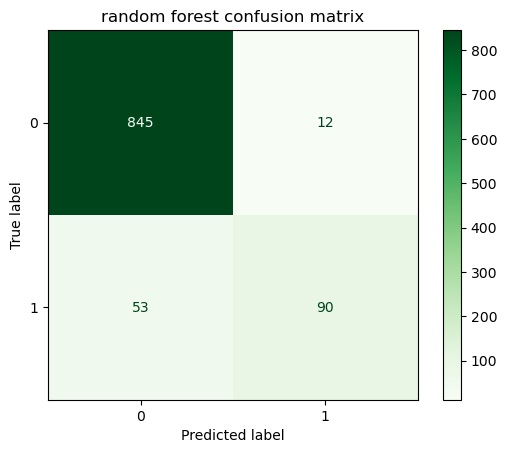

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

rf_model.fit(x_new_train,y_train)

y_pred_rf=rf_model.predict(x_new_test)

print("---random forest classification report----")
print(classification_report(y_test,y_pred_rf))

cm_rf=confusion_matrix(y_test,y_pred_rf)
disp_rf=ConfusionMatrixDisplay(confusion_matrix=cm_rf,display_labels=["0","1"])

disp_rf.plot(cmap=plt.cm.Greens)
plt.title("random forest confusion matrix")
plt.show()

In [24]:
# 1. SMOTE library ko import karein
from imblearn.over_sampling import SMOTE

# 2. SMOTE ka tool initialize karein
smote = SMOTE(random_state=42)

# 3. Sirf Training Data par SMOTE apply karein!
# Yeh X_train aur y_train ko perfectly 50-50 balance kar dega
X_train_smote, y_train_smote = smote.fit_resample(x_new_train, y_train)
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
# Ab aap is naye 'smote' wale data par apna model train kar sakte hain:
rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       0.96      0.95      0.95       857
           1       0.72      0.74      0.73       143

    accuracy                           0.92      1000
   macro avg       0.84      0.85      0.84      1000
weighted avg       0.92      0.92      0.92      1000



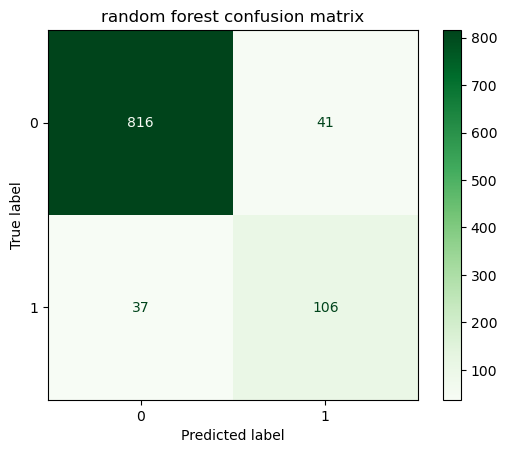

In [25]:
pred=rf_model.predict(x_new_test)
newcm=confusion_matrix(y_test,pred)
print(classification_report(y_test,pred))

disp_rf=ConfusionMatrixDisplay(confusion_matrix=newcm,display_labels=["0","1"])

disp_rf.plot(cmap=plt.cm.Greens)
plt.title("random forest confusion matrix")
plt.show()

In [26]:
confusion_matrix(y_test,pred)

array([[816,  41],
       [ 37, 106]])

In [27]:
model.fit(X_train_smote,y_train_smote)
p=model.predict(x_new_test)
print(classification_report(y_test,p))

              precision    recall  f1-score   support

           0       0.96      0.77      0.86       857
           1       0.38      0.82      0.52       143

    accuracy                           0.78      1000
   macro avg       0.67      0.80      0.69      1000
weighted avg       0.88      0.78      0.81      1000

